### ***Firstly we will Show How Ridge Regression and Alpha Works !***

In [3]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression , Ridge
from sklearn.metrics import r2_score

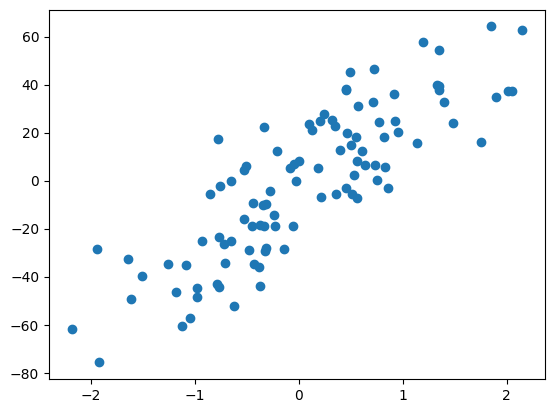

In [28]:
X,y = make_regression(n_samples = 100 , n_features = 1 ,n_informative = 1 ,n_targets = 1 ,noise = 20 , random_state = 13 )

plt.scatter(X,y)

### ***Fitting Linear Regression Model***

In [5]:
lr = LinearRegression()

model = lr.fit(X,y)
y_pred = model.predict(X)
print(f"R2 Score -> {r2_score(y,y_pred)}")
print()
print(f"Weightage -> {model.coef_}")
print(f"Intercept -> {model.intercept_}")

R2 Score -> 0.7035182396294911

Weightage -> [27.82809103]
Intercept -> -2.29474455867698


### ***Fitting Ridge Regression with different Alphas***

--- Alpha = 0---------

R2 Score alpha 0 -> 0.7035182396294912

Weightage -> [27.82809103]
Intercept -> -2.2947445586769804
--- Alpha = 10---------

R2 Score alpha 10 -> 0.6960172225909294

Weightage -> [24.9546267]
Intercept -> -2.1269130035235735
--- Alpha = 100---------

R2 Score alpha 100 -> 0.5020011026155695

Weightage -> [12.93442104]
Intercept -> -1.4248441496033308


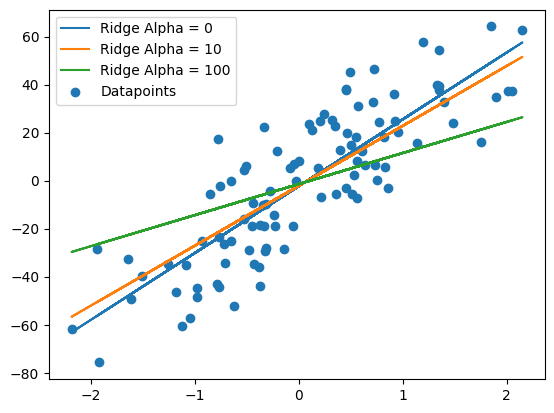

In [8]:
for alphas in [0,10,100]:
    rr = Ridge(alpha = alphas)
    model = rr.fit(X,y)
    y_pred = model.predict(X)
    print(f"--- Alpha = {alphas}---------\n")
    print(f"R2 Score alpha {alphas} -> {r2_score(y,y_pred)}")
    print()
    print(f"Weightage -> {model.coef_}")
    print(f"Intercept -> {model.intercept_}")
    plt.plot(X, y_pred , label = f"Ridge Alpha = {alphas}")
plt.scatter(X,y, label = "Datapoints")
plt.legend()
plt.show()



### ***Ridge Regression 1 Feature From Scratch***

In [36]:
class RidgeRegressor:
    def __init__(self,alpha = 0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self , X , y):
        num =0
        den = 0
        for i in range(X.shape[0]):
            num = num + (X[i] - X.mean()) * (y[i] - y.mean())
            den = den + (X[i] - X.mean()) * (X[i] - X.mean())
        self.m = num/ (den + self.alpha)

        self.b =  np.mean(y) - np.mean(X)*self.m # y mean + m * X mean
        
        print(self.m , self.b)

    def predict(self , X):
        return self.m * X + self.b



In [38]:
rr_from_scratch = RidgeRegressor(100)

rr_from_scratch.fit(X,y) # Fitting Data

print(f"Weightage -> {rr_from_scratch.m}")
print(f"Intercept -> {rr_from_scratch.b}")

y_pred_scratch = rr_from_scratch.predict(X)

print(f"R2 score Scratch -> {r2_score(y , y_pred_scratch)}")

[12.93442104] [-1.42484415]
Weightage -> [12.93442104]
Intercept -> [-1.42484415]
R2 score Scratch -> 0.5020011026155693


In [41]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error , root_mean_squared_error , r2_score
from sklearn.model_selection import train_test_split

In [60]:
X,y = load_diabetes(return_X_y =True)

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = .2 , random_state = 4)

print(f"Shape X_train -> {X_train.shape}")
print(f"Shape X_test -> {X_test.shape}")
print(f"Shape y_train -> {y_train.shape}")
print(f"Shape y_test -> {y_test.shape}")

Shape X_train -> (353, 10)
Shape X_test -> (89, 10)
Shape y_train -> (353,)
Shape y_test -> (89,)


In [79]:
from sklearn.linear_model import Ridge

rr = Ridge(0.1)

rr.fit(X_train , y_train)
y_pred = rr.predict(X_test)

print(f"Intercept -> {rr.intercept_}")
print(f"Weightages -> {rr.coef_}")
print("\n")
print(f"R2 Score Test-> {r2_score(y_test, y_pred)}")
print(f"R2 Score Train-> {r2_score(y_train, mr.predict(X_train).ravel())}")

Intercept -> 150.89053425602808
Weightages -> [  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]


R2 Score Test-> 0.4693128853309805
R2 Score Train-> 0.5185382012699982


### ***Ridge Regression Class For nD Data***

In [75]:
class MeraRidge:
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
    
    def fit(self, X_train , y_train):
        X_train_cons = np.insert(X_train , 0 , 1 , axis = 1) # inserting the constant in first column
        order = X_train_cons.shape[1]
        I = self.alpha * np.eye(order)
        I[0][0] = 0 # We set first diagonal value to zero so that intercept do not change!!

        coefs = (np.linalg.inv(X_train_cons.transpose() @ X_train_cons + I)) @ X_train_cons.transpose() @ y_train

        # This finds the coefficients including intercept and weightages

        self.b = coefs[0] # intercept
        self.m = coefs[1:]  # weightage

        print(self.m , self.b)

    def predict(self, X_test):
        return X_test @ self.m + self.b             # @ is same as np.dot(X_test , self.m)



In [77]:
mr = MeraRidge(0.1) # Forming object for MeraRidge Class with alpha = 0.1

mr.fit(X_train,y_train) # Fitting the model with X_train and y_train

y_pred = mr.predict(X_test) # Finding the predicted values as per the values of intercept and weightages

print(f"R2 Score Test-> {r2_score(y_test, y_pred)}")
print(f"R2 Score Train-> {r2_score(y_train, mr.predict(X_train).ravel())}")

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681] 150.8905342560281
R2 Score Test-> 0.4693128853309806
R2 Score Train-> 0.5185382012699982


### ***Important thing to NOTE***

***When using Ridge class from sklearn library -> When They form Identity matrix, they are setting the First diagonal value to zero, as they do not want to manipulate the Intercept term with (Alpha)***